# **Домашнее задание DLS #5. Классификация изображений персонажей из сериала Симпсоны**

Team_name на kaggle: Евгений_Ильницкий_991877416

## **Подготовка к работе**

### Импорты библиотек

In [ ]:
import torch
import numpy as np
import pandas as pd
from matplotlib import colors, pyplot as plt

from PIL import Image
from collections import Counter
from google.colab import drive
import os

import torch.optim as optim
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision.utils import make_grid




### Подключаем Cuda

In [ ]:
train_on_gpu = torch.cuda.is_available()

# Проверяем, работает ли CUDA

if not train_on_gpu:
  print('CUDA is not available. training on CPU')
else:
  print('CUDA is available. training on GPU')

CUDA is available. training on GPU


### Скачиваем датасет

In [ ]:
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
!unzip -q /content/gdrive/MyDrive/journey-springfield.zip

In [ ]:
!ls train

simpsons_dataset


In [ ]:
!ls train/simpsons_dataset

abraham_grampa_simpson	  groundskeeper_willie	ned_flanders
agnes_skinner		  homer_simpson		nelson_muntz
apu_nahasapeemapetilon	  kent_brockman		otto_mann
barney_gumble		  krusty_the_clown	patty_bouvier
bart_simpson		  lenny_leonard		principal_skinner
carl_carlson		  lionel_hutz		professor_john_frink
charles_montgomery_burns  lisa_simpson		rainier_wolfcastle
chief_wiggum		  maggie_simpson	ralph_wiggum
cletus_spuckler		  marge_simpson		selma_bouvier
comic_book_guy		  martin_prince		sideshow_bob
disco_stu		  mayor_quimby		sideshow_mel
edna_krabappel		  milhouse_van_houten	snake_jailbird
fat_tony		  miss_hoover		troy_mcclure
gil			  moe_szyslak		waylon_smithers


## **Параметры**

In [ ]:
train_dir = './train/simpsons_dataset'
test_dir = './testset/testset'
BATCH_SIZE = 32
NUM_EPOCHS = 10
NUM_CLASSES = len(os.listdir(train_dir))  # Количество классов = количество подпапок
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



---


## **Предобработка данных**

### Проверяем количество картинок в каждой категории

In [ ]:
for folder_name in os.listdir(train_dir):
        folder_path = os.path.join(train_dir, folder_name)
        if os.path.isdir(folder_path):
            files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
            print(f"Папка '{folder_name}': {len(files)} файлов")

Папка 'ned_flanders': 1454 файлов
Папка 'edna_krabappel': 457 файлов
Папка 'disco_stu': 8 файлов
Папка 'marge_simpson': 1291 файлов
Папка 'troy_mcclure': 8 файлов
Папка 'lionel_hutz': 3 файлов
Папка 'apu_nahasapeemapetilon': 623 файлов
Папка 'agnes_skinner': 42 файлов
Папка 'barney_gumble': 106 файлов
Папка 'otto_mann': 32 файлов
Папка 'homer_simpson': 2246 файлов
Папка 'cletus_spuckler': 47 файлов
Папка 'ralph_wiggum': 89 файлов
Папка 'selma_bouvier': 103 файлов
Папка 'comic_book_guy': 469 файлов
Папка 'charles_montgomery_burns': 1193 файлов
Папка 'waylon_smithers': 181 файлов
Папка 'snake_jailbird': 55 файлов
Папка 'principal_skinner': 1194 файлов
Папка 'maggie_simpson': 128 файлов
Папка 'miss_hoover': 17 файлов
Папка 'martin_prince': 71 файлов
Папка 'carl_carlson': 98 файлов
Папка 'chief_wiggum': 986 файлов
Папка 'kent_brockman': 498 файлов
Папка 'groundskeeper_willie': 121 файлов
Папка 'lenny_leonard': 310 файлов
Папка 'professor_john_frink': 65 файлов
Папка 'mayor_quimby': 246 фай

Делаем вывод, что датасет несбалансирован, поэтому будем использовать WeightedRandomSampler

### Определяем transfrom: аугментация, размер (224x224), преобразование в Tensor

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # Большинство предобученных моделей (ResNet, VGG и др.) обучались на ImageNet с такой нормализацией.
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### Загружаем обучающий датасет, распределенный по папкам-категориям

In [ ]:
dataset = datasets.ImageFolder(  # ImageFolder - встроенная функция для датасетов, распределнных по папкам в зависимости от класса
    root=train_dir,
    transform=train_transform # вначале применяем train_transform для всего датасета
)
# Разделяем на train и val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_dataset.dataset.transform = val_test_transform # меняем у val_dataset transform на валидационный

### Из-за несбаласированности будем использовать функцию WeightedRandomSampler

In [ ]:
def get_sampler(dataset):
  targets = [dataset.dataset.targets[i] for i in dataset.indices] # dataset.dataset - обращение к оригинальному датасету/ dataset.indices - это индексы элементов, попавших в текущее подмножество
  class_counts = Counter(targets)
  class_weights = {cls: 1. / count for cls, count in class_counts.items()}
  weights = [class_weights[cls] for cls in targets] # веса для каждой картинки
  sampler = WeightedRandomSampler(weights, len(weights))
  return sampler

### Создаем Loaders

In [ ]:
train_sampler = get_sampler(train_dataset) # в train_loader передадим данный sampler

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### Создаем класс для тестовых картинок, у которых нет разметки по категориям

In [ ]:
class test_images_dataset(Dataset):
  def __init__(self, dir=test_dir, transform=val_test_transform):
    self.dir = dir
    self.transform = transform
    self.imgs_files = sorted([img for img in os.listdir(dir)])

  def __len__(self):
    return len(self.imgs_files)

  def __getitem__(self, idx):
    img_path = os.path.join(self.dir, self.imgs_files[idx])
    image = Image.open(img_path).convert('RGB')

    image = self.transform(image)

    return image, self.imgs_files[idx]

In [ ]:
test_dataset = test_images_dataset(dir=test_dir, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

### Проверяем, что картинки действительно загрузились в loaders

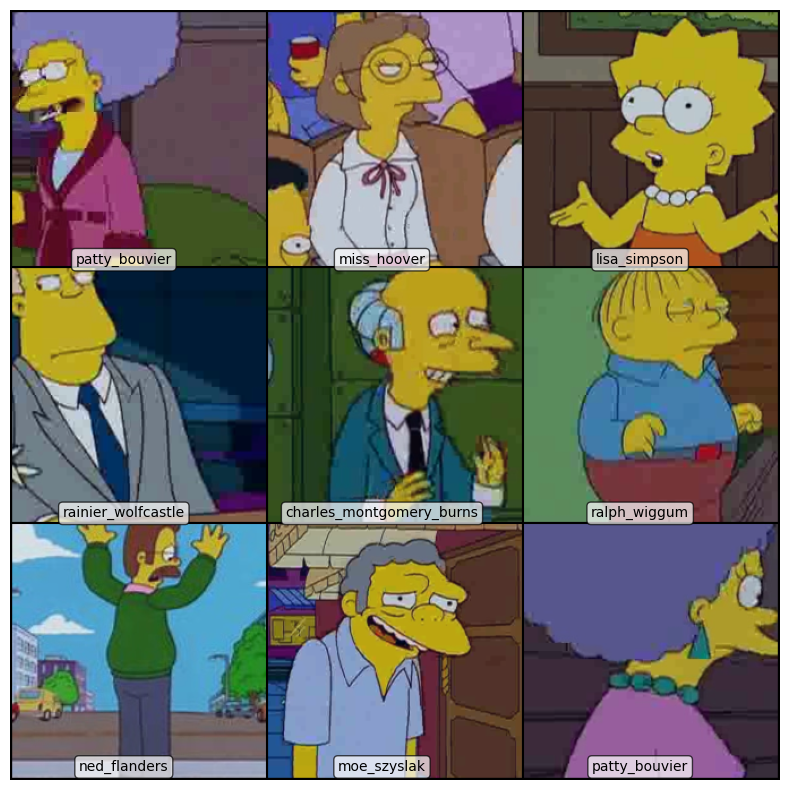

In [ ]:
images, labels = next(iter(train_loader))
class_names = train_dataset.dataset.classes
n_images = 9

# Ограничиваем количество изображений
images = images[:n_images]
labels = labels[:n_images]

# Создаем сетку изображений
grid = make_grid(images, nrow=3, padding=2, normalize=True)

# Преобразуем тензор в numpy и меняем порядок осей
np_grid = grid.numpy().transpose((1, 2, 0))

# Создаем фигуру
plt.figure(figsize=(12, 8))
plt.imshow(np_grid)
plt.axis('off')

# Добавляем подписи классов под каждым изображением
for i, (image, label) in enumerate(zip(images, labels)):
  plt.text(
    (i % 3) * (224 + 4) + 100,  # X координата (3 изображения в строке)
    (i // 3) * (224) + 220,  # Y координата (2 строки)
    class_names[label],            # Название класса
    ha='center',
    va='center',
    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round')
  )

plt.tight_layout()
plt.show()



---


## **Cоздаем модель**

### Модель, оптимизатор, критерий

In [ ]:
model_resnet18 = models.resnet18(pretrained=True) # предобучений resnet18
model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, NUM_CLASSES) # меняем последний слой под наше количество выходов
model_resnet18 = model_resnet18.to(DEVICE)

optimizer = optim.AdamW(model_resnet18.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


### Функция постепенного размораживания слоев

In [ ]:
def unfreeze_layers(model, epoch):
  # вначале обучаем только последний слой
  if epoch < 5:
    for par in model.parameters():
      par.requires_grad = False
    for par in model.fc.parameters():
      par.requires_grad = True
  # потом размораживаем 2 блока
  if 5 <= epoch < 8:
    for name, par in model.named_parameters():
      if 'layer4' in name or 'fc' in name:
        par.requires_grad = True
      else:
        par.requires_grad = False
  else:
    for par in model.parameters():
      par.requires_grad = True

### Функция обучения

In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, classes=dataset.classes):
  best_acc = 0.0
  history = []

  # Фаза обучения
  for epoch in range(epochs):
    print(f'Epoch {epoch}/{epochs - 1}')


    unfreeze_layers(model, epoch) # поэтапное размораживание слоев

    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)

      optimizer.zero_grad()

      outputs = model(inputs)
      preds = torch.argmax(outputs, 1)
      loss = criterion(outputs, labels)

      loss.backward()
      optimizer.step()

      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)

    train_epoch_loss = running_loss / len(train_dataset)
    train_epoch_acc = running_corrects.double() / len(train_dataset) # .double() - преобразование в тип torch.float64
    print(f'Train Loss : {train_epoch_loss:.4f} Acc: {train_epoch_acc:.4f}')

    # Фаза валидации
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    for inputs, labels in val_loader:
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)

      with torch.no_grad():
        outputs = model(inputs)
        preds = torch.argmax(outputs, 1)
        loss = criterion(outputs, labels)

      val_loss += loss.item() * inputs.size(0)
      val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects.double() / len(val_dataset)
    print(f'Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}')
    print('-' * 10)

    if val_epoch_acc > best_acc:
      best_acc = val_epoch_acc
      torch.save({
          'model_state_dict': model.state_dict(),
          'classes': classes
      }, 'best_model_with_classes.pth')

    history.append((train_epoch_loss, train_epoch_acc, val_epoch_loss, val_epoch_acc))

  print(f'Best val acc: {best_acc:.4f}')

  return history

### Функция предсказания

In [ ]:
def predict_imgs_from_folder(test_loader, model, model_path='best_model_with_classes.pth', batch_size=BATCH_SIZE):

  loaded_checkpoint = torch.load(model_path)

  model.load_state_dict(loaded_checkpoint['model_state_dict'])  # загружаем веса с эпохи с лучшим значением val_acc

  model = model.to(DEVICE)
  model.eval()

  with torch.no_grad():
    logits = []
    for inputs, _ in test_loader:
      inputs = inputs.to(DEVICE)
      outputs = model(inputs).cpu()
      logits.append(outputs)

  probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
  return probs

## Обучаем модель

### Запускаем функцию обучения

In [ ]:
history = train(model_resnet18, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, BATCH_SIZE)

Epoch 0/9
Train Loss : 0.0212 Acc: 0.9963
Val Loss: 0.1745 Acc: 0.9599
----------
Epoch 1/9
Train Loss : 0.0223 Acc: 0.9955
Val Loss: 0.1671 Acc: 0.9625
----------
Epoch 2/9
Train Loss : 0.0132 Acc: 0.9975
Val Loss: 0.1534 Acc: 0.9690
----------
Epoch 3/9
Train Loss : 0.0192 Acc: 0.9971
Val Loss: 0.1544 Acc: 0.9651
----------
Epoch 4/9
Train Loss : 0.0161 Acc: 0.9971
Val Loss: 0.1561 Acc: 0.9666
----------
Epoch 5/9
Train Loss : 0.0064 Acc: 0.9988
Val Loss: 0.1558 Acc: 0.9656
----------
Epoch 6/9
Train Loss : 0.0060 Acc: 0.9986
Val Loss: 0.1631 Acc: 0.9647
----------
Epoch 7/9
Train Loss : 0.0064 Acc: 0.9990
Val Loss: 0.1554 Acc: 0.9680
----------
Epoch 8/9
Train Loss : 0.0167 Acc: 0.9961
Val Loss: 0.1927 Acc: 0.9529
----------
Epoch 9/9
Train Loss : 0.0188 Acc: 0.9952
Val Loss: 0.1808 Acc: 0.9599
----------
Best val acc: 0.9690


### Визуализируем train_loss и val_loss

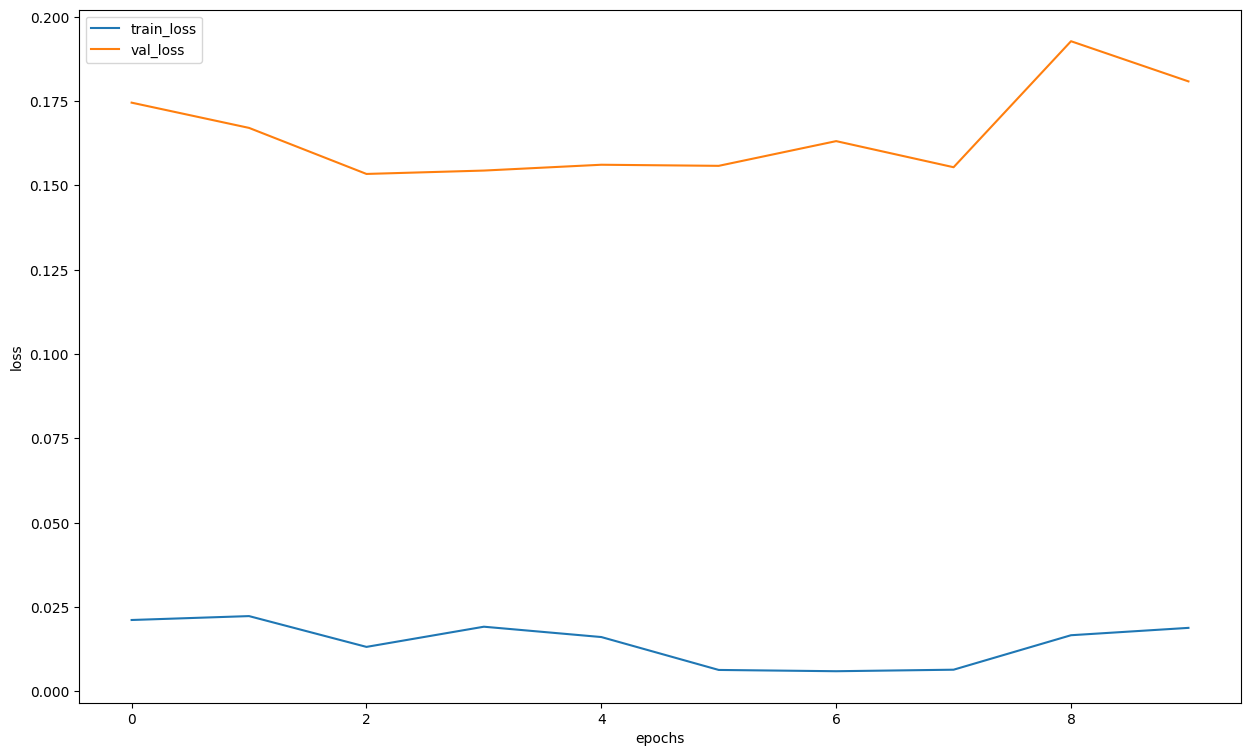

In [ ]:
loss, acc, val_loss, val_acc = zip(*history)
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

## Предсказываем классы тестовых данных

In [ ]:
probs = predict_imgs_from_folder(test_loader, model_resnet18, model_path='best_model_with_classes.pth', batch_size=BATCH_SIZE)

predicted_indices = np.argmax(probs, axis=1)
predicted_labels = [dataset.classes[idx] for idx in predicted_indices]

test_filenames = sorted(test_dataset.imgs_files)

In [ ]:
my_submit = pd.read_csv("/content/sample_submission.csv")
my_submit = pd.DataFrame({'Id': test_filenames, 'Expected': predicted_labels})

In [ ]:
my_submit.to_csv('simple_cnn_baseline.csv', index=False)